In [1]:
from NeuronDataProcess import*
from typing import Dict, Literal

CreatedDataPerDayInstances:Dict[str, DataPerDay] = {}
CreatedDayInstancesProperties:dict = {}

def GetInstanceBy(mode:Literal['MouseName', 'Day'], nameArg, dayArg = None):
    assert mode in ['MouseName', 'Day']
    assert mode == 'MouseName' and isinstance(nameArg, str) or mode == 'Day' and isinstance(nameArg, str) and isinstance(dayArg, int)
    relatedInstances = []
    if mode == 'MouseName':
        relatedInstances = [CreatedDataPerDayInstances[path] for path in CreatedDataPerDayInstances.keys() if CreatedDayInstancesProperties[path]['name'] == nameArg]
    else:
        relatedInstances = [CreatedDataPerDayInstances[path] for path in CreatedDataPerDayInstances.keys() if (CreatedDayInstancesProperties[path]['name'] == nameArg and CreatedDayInstancesProperties[path]['day'] == dayArg)]
    return relatedInstances

def GetMouseNames()-> list[str]:
    if len(CreatedDataPerDayInstances) == 0:
        return []
    return list(set([_inst['name'] for _inst in CreatedDayInstancesProperties.values()]))

def GetAvailableDays(mouseName:str) -> list[int]:
    if len(CreatedDataPerDayInstances) == 0:
        return []
    return list(set([_inst['day'] for _inst in CreatedDayInstancesProperties.values() if _inst['name'] == mouseName]))

def GetAvailableInstances() -> Dict[str, List[int]]:
    if len(CreatedDataPerDayInstances) == 0:
        return {}
    mouseNames = GetMouseNames()
    availableInstances = {}
    for mouseName in mouseNames:
        availableInstances[mouseName] = GetAvailableDays(mouseName)
    return availableInstances
    

In [2]:
_cur, _instance = CreateDayInstance(r"D:\Unity\PythonFiles\Logs\0720-0724\#output\1_7_day0_summary.pkl", r"D:\Unity\PythonFiles\Logs\0720-0724\#output\1_7\1_7_day_0\Cell_trance_1_7_0_hdf5_files.pkl")
if _instance is not None:
    CreatedDataPerDayInstances[_cur] = _instance
    CreatedDayInstancesProperties[_cur] = {"name":_instance.name, "day":_instance.day}

mouse 1_7 Day 0 loaded from file:D:\Unity\PythonFiles\Logs\0720-0724\#output/1_7_day0_summary.pkl.


participation_ratios(blue) and concentration_ratios(yellow) as below


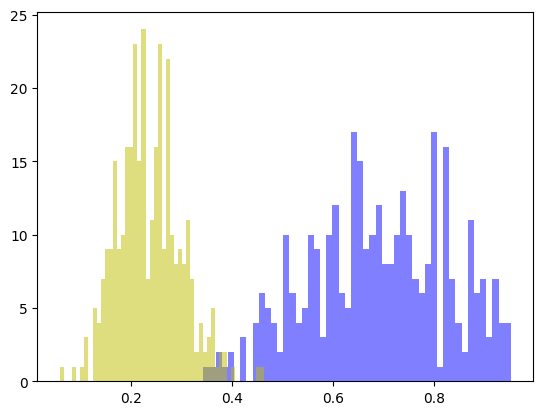

23
[ 47  50  58  64  77  78  93 104 117 121 137 145 158 162 202 205 213 224
 237 245 249 281 286]


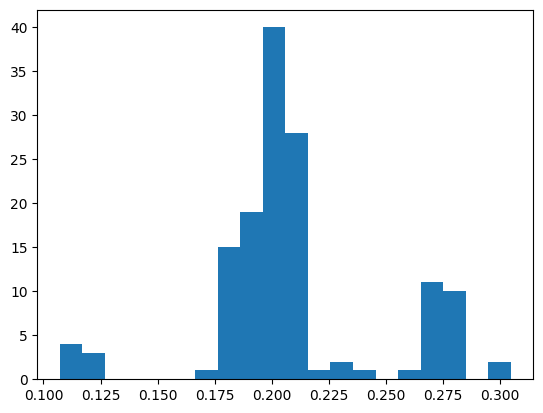

57
[  7  12  23  37  40  44  46  47  64  71  79  80  87  90  93 104 107 113
 117 118 124 129 132 133 135 137 139 142 145 158 162 164 181 186 202 205
 224 228 237 249 253 257 262 263 267 268 279 281 284 301 304 311 314 317
 323 329 330]


array([ 47,  64,  93, 104, 117, 137, 145, 158, 162, 202, 205, 224, 237,
       249, 281])

In [3]:
neuronFireAtRewardPlace = _instance.GetActiveNeuronIndexInSelectedRegion((933, 471), 25, 0.38, 0.7, 0.33)
print(len(neuronFireAtRewardPlace))
print(neuronFireAtRewardPlace)
_trialStartTime, _trialInTargetTime, _trialEndTime = np.vstack(_instance.dayInstance.trialTimeMarkCollected).T
neuronFireAtRewardTime = _instance.GetActiveNeuronIndexInSelectedTime(_trialEndTime-0.2, _trialEndTime+0.8, 0.4, 0.7, False)
print(len(neuronFireAtRewardTime))
print(neuronFireAtRewardTime)
neuronBothFireAtRewardTimeAndPlace = np.intersect1d(neuronFireAtRewardTime, neuronFireAtRewardPlace)
_instance.ShowSingleNeuronFiringMap(neuronBothFireAtRewardTimeAndPlace, fillWithRandomCells=False, cutPeakAtReward=False)

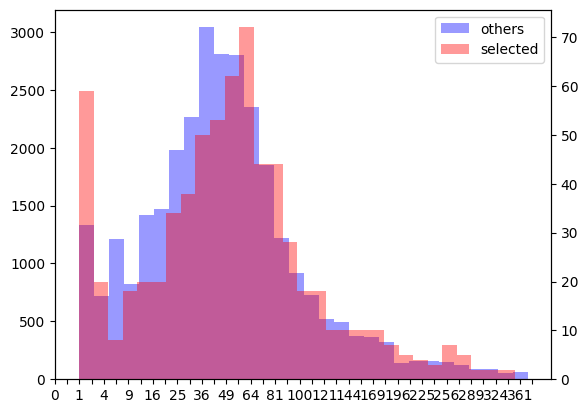

In [6]:
tempActivityInd, tempActivity = _instance.GetNeuronActivityInSelectedTime(_trialEndTime[:-1], _trialInTargetTime[1:])
tempActivityPeak = tempActivity > np.percentile(tempActivity, 70, axis = 1)[:, np.newaxis]
tempActivityPeakSeleted = tempActivityPeak[neuronBothFireAtRewardTimeAndPlace]
tempActivityPeak = tempActivityPeak[np.setdiff1d(np.arange(len(tempActivityPeak)), neuronBothFireAtRewardTimeAndPlace)]

lengths = [len(sublist) for sublist in tempActivityInd]
temp = np.split(np.arange(sum(lengths)), np.cumsum(lengths)[:-1])

intervals = []
intervalsSelected = []
for seg in temp:
    tempRes = [np.arange(len(seg))[mask] for mask in tempActivityPeak[:, seg]]
    tempRes = [[s[0] for s in auto_segment(tempR, 10)] for tempR in tempRes if len(tempR)]
    tempRes = np.concatenate(tempRes)
    intervals.append(tempRes[tempRes > 0])

    tempRes = [np.arange(len(seg))[mask] for mask in tempActivityPeakSeleted[:, seg]]
    tempRes = [[s[0] for s in auto_segment(tempR, 10)] for tempR in tempRes if len(tempR)]
    tempRes = np.concatenate(tempRes)
    intervalsSelected.append(tempRes[tempRes > 0])
intervals = np.concatenate(intervals)
intervalsSelected = np.concatenate(intervalsSelected)
intervalsSelected = np.sqrt(intervalsSelected) if np.max(intervals) > 100 else intervalsSelected
intervals = np.sqrt(intervals) if np.max(intervals) > 100 else intervals
axe:plt.Axes = plt.subplot(111)
_, _, _ip = axe.hist(intervals, bins = 30, alpha = 0.4, color = 'b', label="others")
_, _, _ips = axe.twinx().hist(intervalsSelected, bins = 30, alpha = 0.4, color = 'r', label = "selected")
axe.set_xticks(np.arange(0, 20, 0.5), [(str(int(num ** 2)) if num.is_integer() else "") for num in np.arange(0, 20, 0.5)])
axe.legend([_ip, _ips], [p[0].get_label() for p in [_ip, _ips]])
plt.show()

d:\MiniConda\envs\logProcessMth\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
d:\MiniConda\envs\logProcessMth\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
d:\Unity\PythonFiles\NeuronDataProcess.py:465: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  _fig.show()


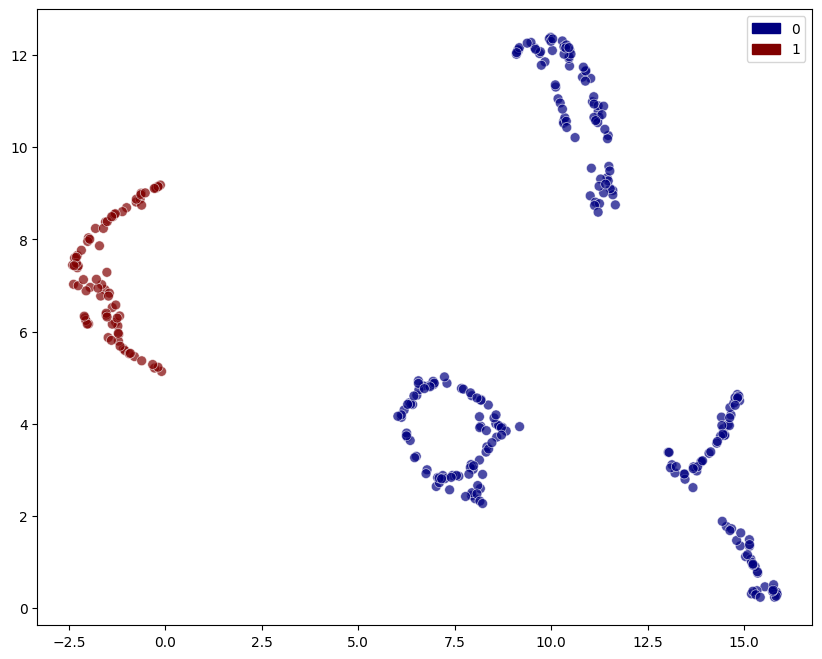

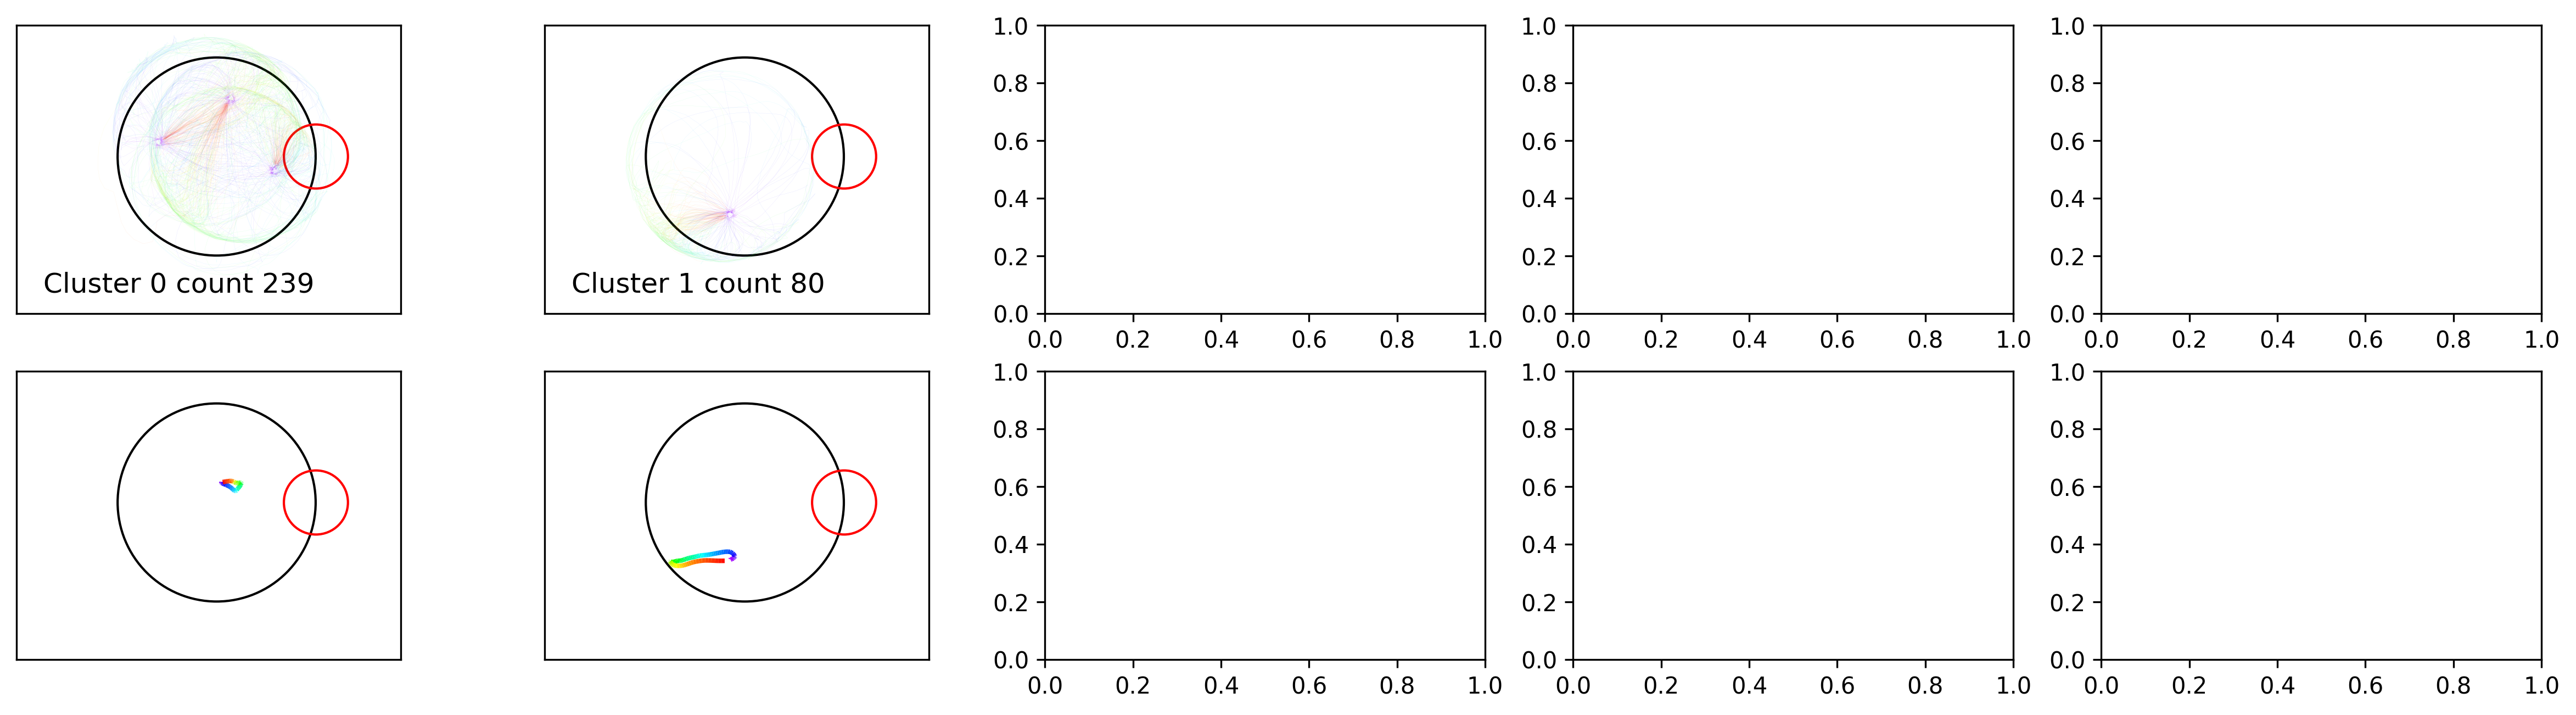

now data rows: 9477
taskStage pearson correlation coefficient: PearsonRResult(statistic=np.float64(0.3467217972324873), pvalue=np.float64(1.8953491211092547e-187))
HeadDir pearson correlation coefficient: PearsonRResult(statistic=np.float64(0.07718224531424184), pvalue=np.float64(2.6191558050256606e-17))
HeadDirDelta pearson correlation coefficient: PearsonRResult(statistic=np.float64(0.08434768874057984), pvalue=np.float64(3.182235418982817e-07))
Speed pearson correlation coefficient: PearsonRResult(statistic=np.float64(0.09576152002448443), pvalue=np.float64(1.3869618134158617e-40))


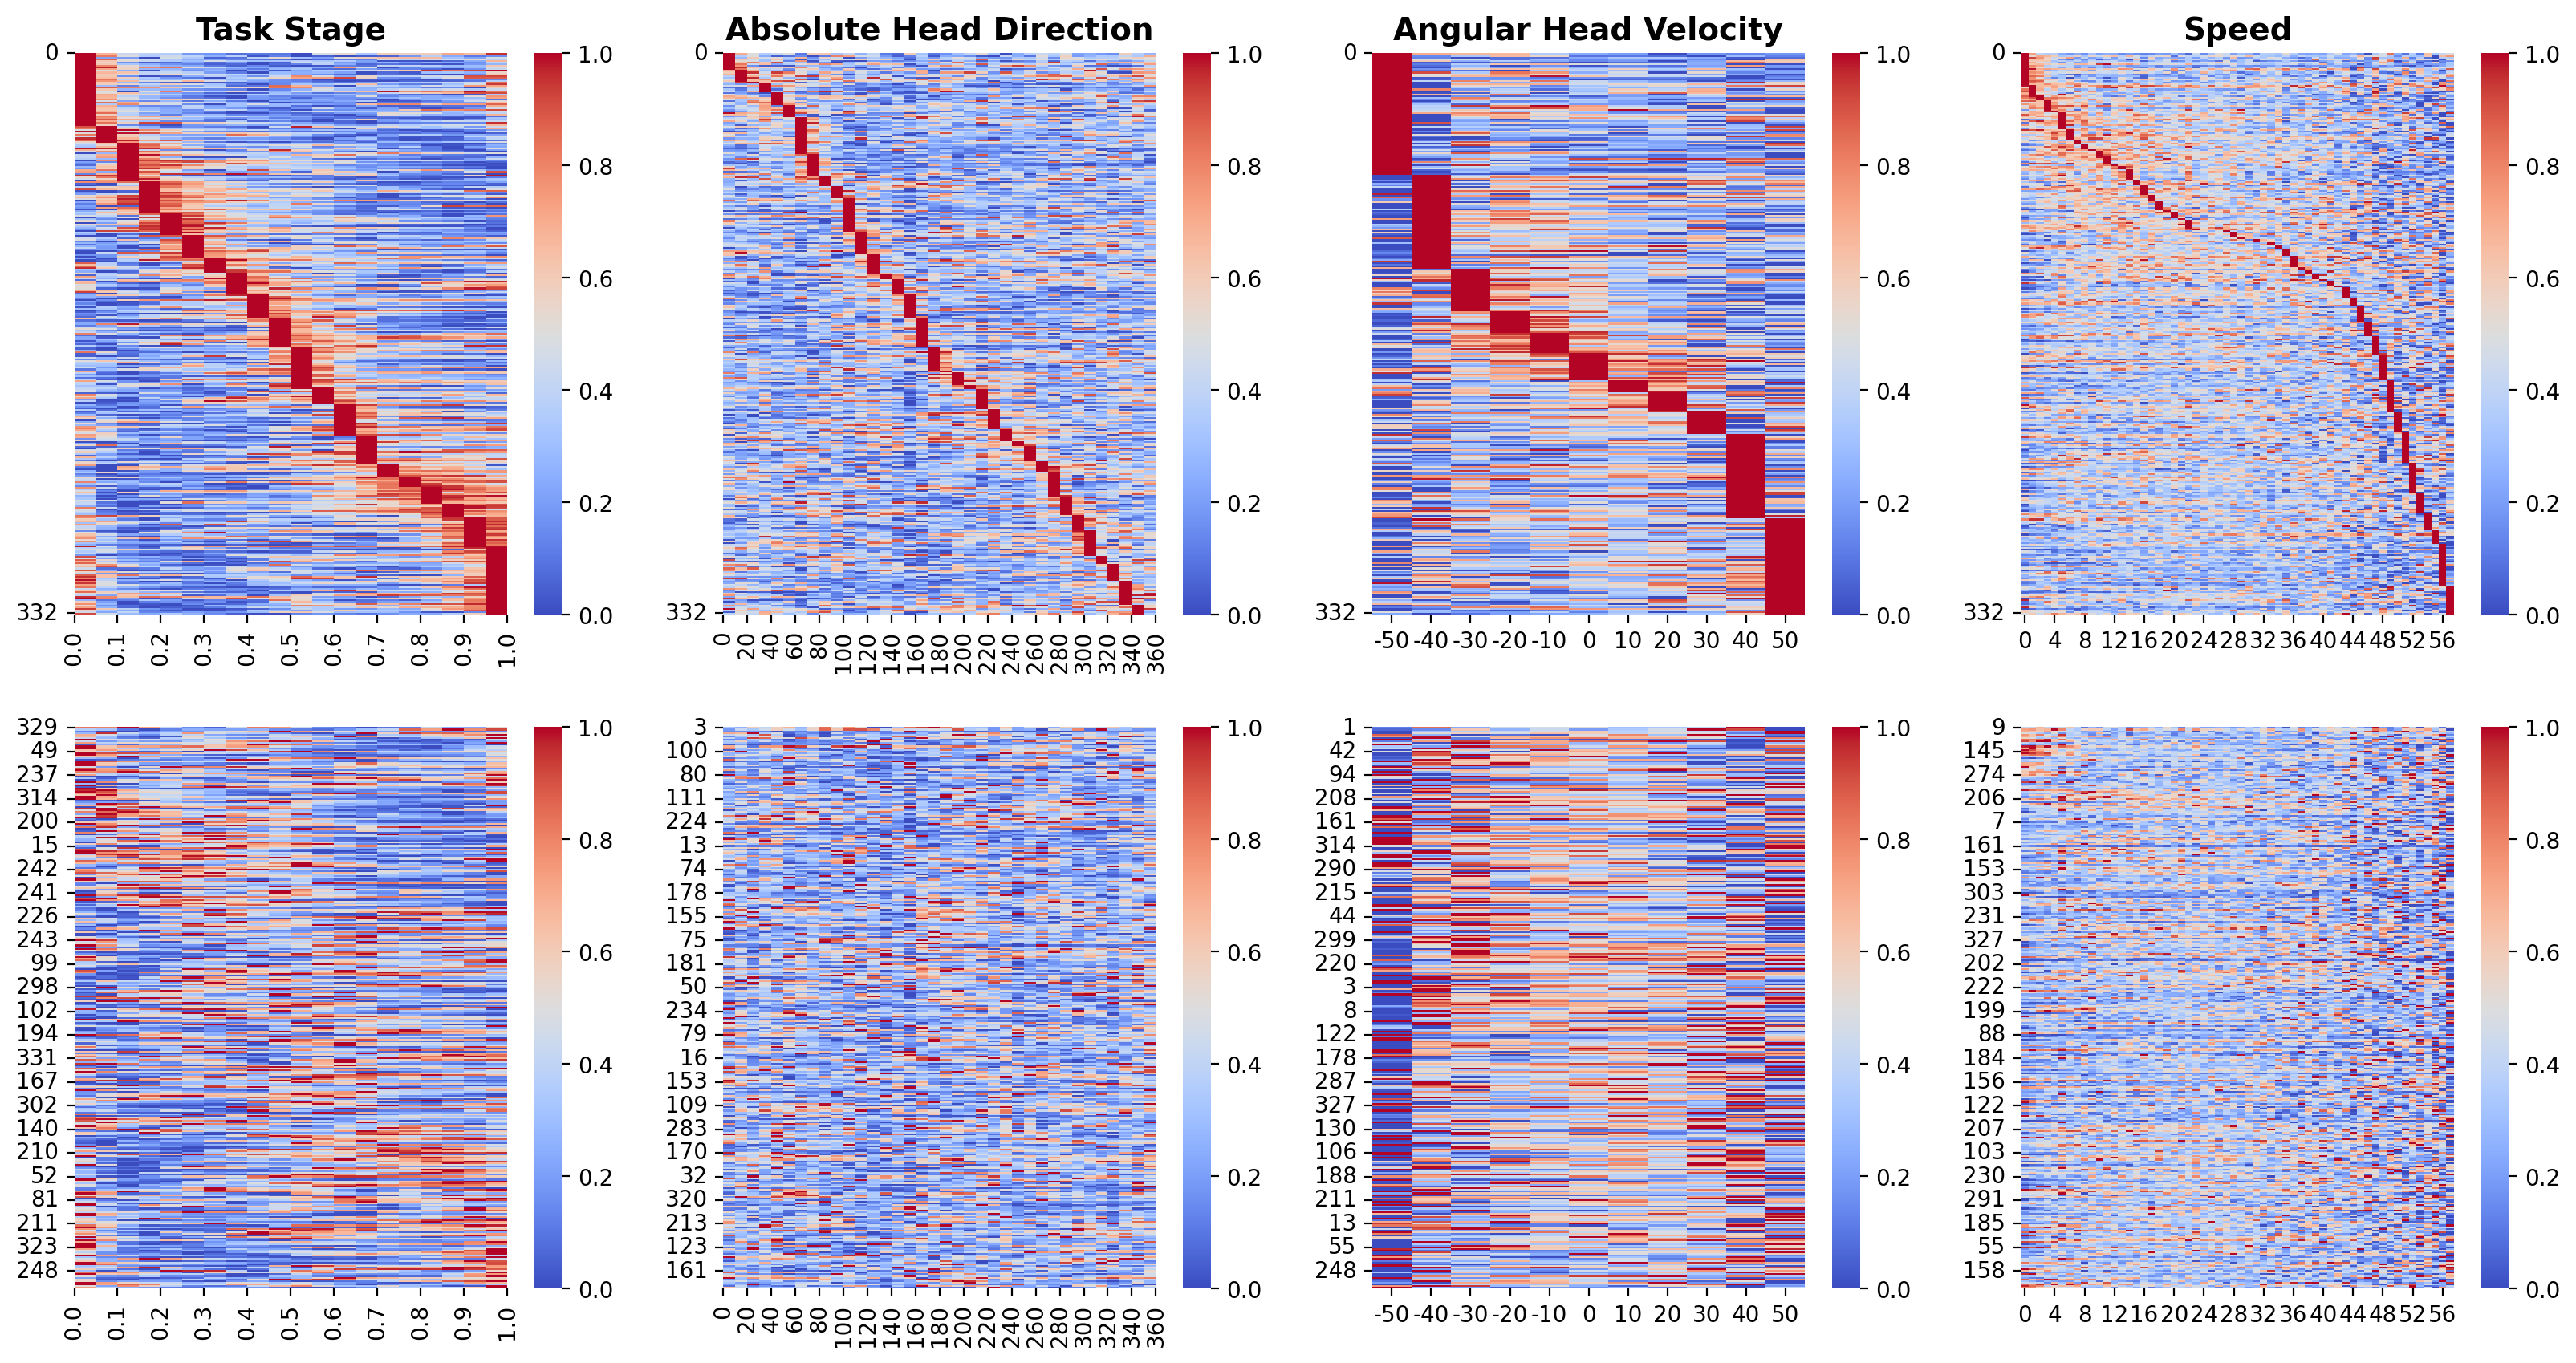

now data rows: 3479
taskStage pearson correlation coefficient: PearsonRResult(statistic=np.float64(0.14609697599029545), pvalue=np.float64(4.262537321545208e-33))
HeadDir pearson correlation coefficient: PearsonRResult(statistic=np.float64(0.04052068206615601), pvalue=np.float64(9.081620178756267e-06))
HeadDirDelta pearson correlation coefficient: PearsonRResult(statistic=np.float64(0.028118933979054926), pvalue=np.float64(0.12379714089428431))
Speed pearson correlation coefficient: PearsonRResult(statistic=np.float64(0.04495566734433391), pvalue=np.float64(4.2119335109494843e-07))


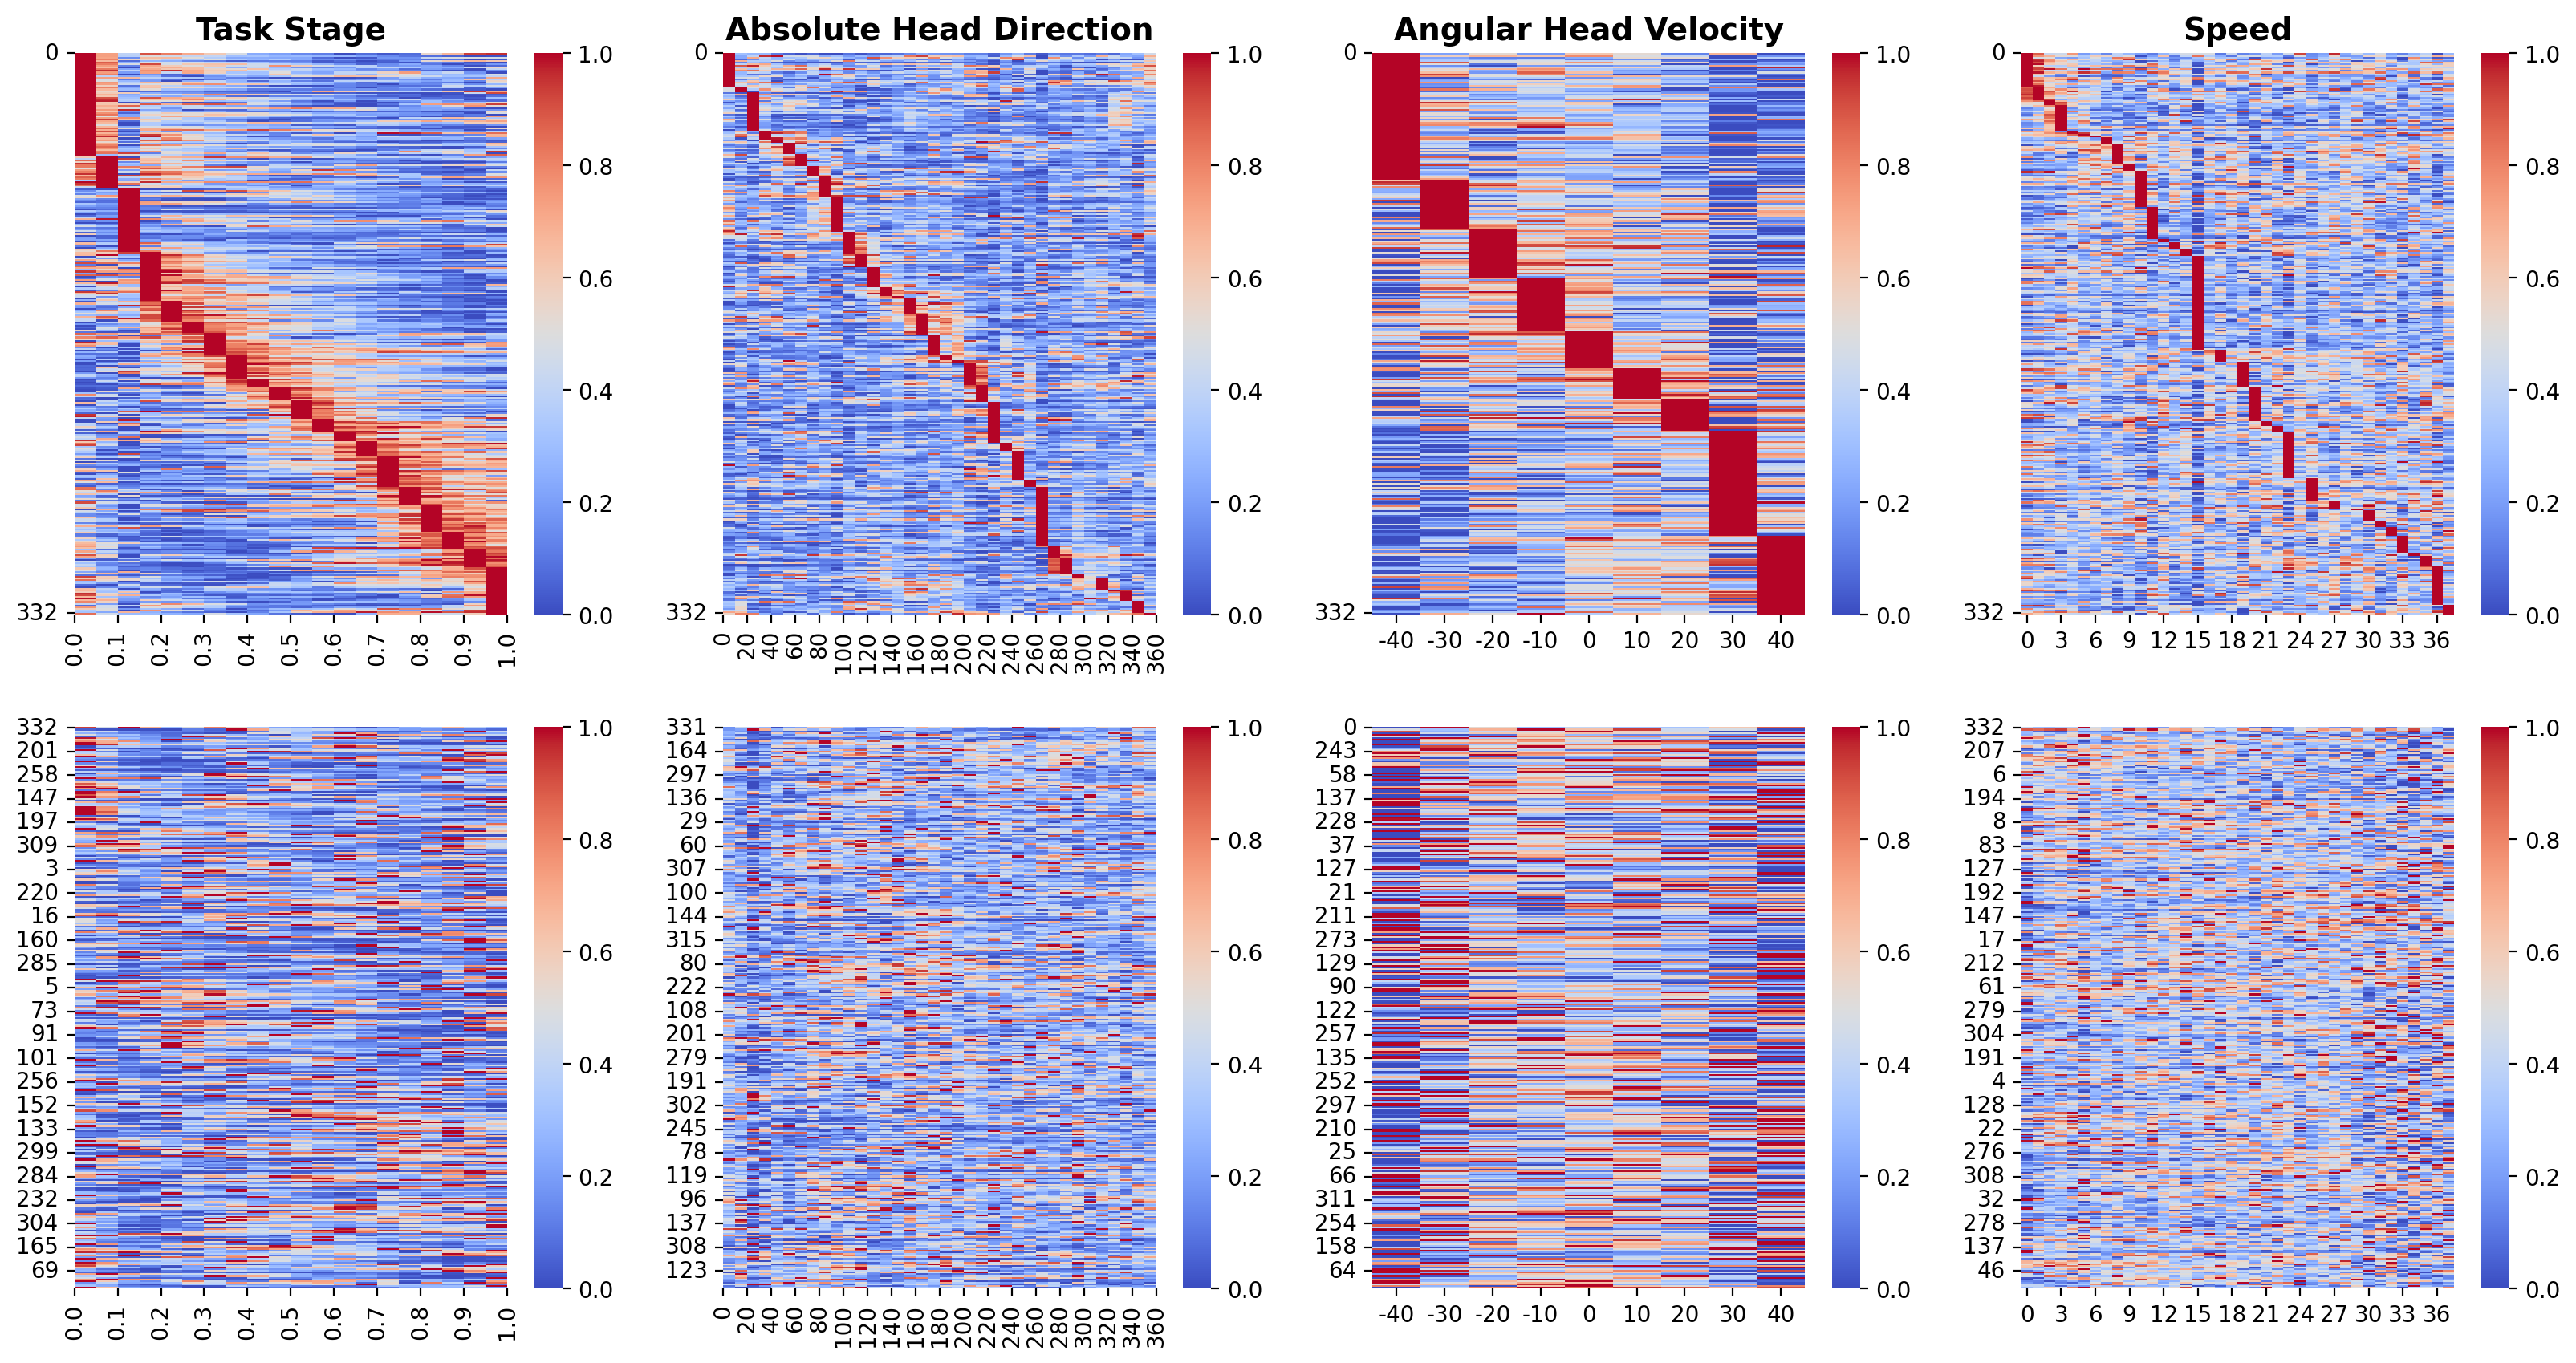

In [ ]:
_instance.ResampleAndClusterMouseTracks()
_instance.ShowNeuronActivityAlignWithOffset(None)

In [4]:
assignId = _instance.ShowSingleNeuronFiringMap([263, 185, 330, 205, 96, 327, 0, 133, 304, 297, 46, 128, 260], fillWithRandomCells=True)

In [ ]:
assignId = [263, 185, 330, 205,  96, 327,   0, 133, 304, 297,  46, 128, 260,
       177, 181, 319, 268, 111,  88, 226]
_instance.ShowSingleNeuronFiringMap(assignId, 0.8)

array([263, 185, 330, 205,  96, 327,   0, 133, 304, 297,  46, 128, 260,
       177, 181, 319, 268, 111,  88, 226])

In [ ]:
_instance.ShowSingleNeuronFiringMap(assignId, +0.2)

array([263, 185, 330, 205,  96, 327,   0, 133, 304, 297,  46, 294, 292,
        63, 148, 236,  61, 201, 238,  86])